## O que é o Indicador Criança Alfabetizada

Links / referências<br/>
https://www.gov.br/mec/pt-br (política educacional)<br/>
Dados: camada **Gold** do datalake da Fase 2 — `gold/br_inep_alfabetizacao/`

O Indicador Criança Alfabetizada acompanha se crianças em idade escolar atingem o nível esperado de alfabetização. Na Fase 3 usamos a Gold já integrada (aluno, território, metas e contexto socioeconômico) para **prever** se um aluno será considerado alfabetizado (`alfabetizado` = 0 ou 1) e gerar inteligência para gestores públicos.

Trabalhamos com quatro tabelas Gold:
- **`alunos_features`** — fato por aluno (target da modelagem)
- **`contexto_territorio`** — município × rede (PIB, IVS, lags)
- **`indicador_crianca_alfabetizada_municipio`** — taxas e metas municipais
- **`indicador_crianca_alfabetizada_uf`** — taxas e metas por UF


**Pergunta Norteadora:**  
*"Quais fatores educacionais, territoriais e socioeconômicos estão associados à alfabetização do aluno, e como isso apoia a escolha de features e o cuidado com data leakage na modelagem?"

In [1]:
# Libs
from pathlib import Path
import importlib
import sys
import warnings

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
sns.set_style("darkgrid")

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# Recarrega módulos após alterações no código (evita cache do kernel)
for mod in ("src.config", "src.visualization.eda", "src.preprocessing.load_s3"):
    if mod in sys.modules:
        importlib.reload(sys.modules[mod])

import src.config as config
importlib.reload(config)

from src.config import DATALAKE_BUCKET, EDA_N_ROWS, GOLD_PREFIX, GOLD_YEAR, IMAGES_DIR, LEAKAGE_COLS, TARGET_COL
from src.visualization.eda import (
    build_eda_frame,
    correlation_with_target,
    feature_columns,
    load_eda_data,
    profile,
    split_feature_types,
    target_balance,
    write_eda_report,
)

pd.set_option("display.max_columns", 40)
IMAGES_DIR.mkdir(parents=True, exist_ok=True)
print(f"Fonte: s3://{DATALAKE_BUCKET}/{GOLD_PREFIX} | ano={GOLD_YEAR} | n_alunos={EDA_N_ROWS}")


Fonte: s3://tech-challenge-2-datalake-prod/gold/br_inep_alfabetizacao | ano=2024 | n_alunos=5000


### Leitura da base (Gold no S3)

Leitura **sempre** do datalake AWS:

`s3://{DATALAKE_BUCKET}/gold/br_inep_alfabetizacao/{tabela}/ano={GOLD_YEAR}/`

- **`alunos_features`:** `EDA_N_ROWS` linhas **sorteadas aleatoriamente** entre row groups (seed fixa, cache em data/processed/)
- **Demais tabelas:** partição completa do ano (são pequenas)

Credenciais AWS no `.env` (`AWS_ACCESS_KEY_ID`, `AWS_SECRET_ACCESS_KEY`, região).


In [2]:
tables = load_eda_data()
alunos = tables["alunos_features"]
contexto = tables["contexto_territorio"]
ind_mun = tables["indicador_crianca_alfabetizada_municipio"]
ind_uf = tables["indicador_crianca_alfabetizada_uf"]

alunos.head()

,id_aluno,id_municipio,rede,serie,alfabetizado,peso_aluno,_ingestion_timestamp,_silver_processed_at,_silver_batch_id,meta_alfabetizacao_2024,meta_alfabetizacao_2025,meta_alfabetizacao_2026,meta_alfabetizacao_2027,meta_alfabetizacao_2028,meta_alfabetizacao_2029,meta_alfabetizacao_2030,nivel_alfabetizacao,_source_table,_batch_id,nome_municipio,...,lag1_proporcao_aluno_nivel_2,lag1_proporcao_aluno_nivel_3,lag1_proporcao_aluno_nivel_4,lag1_proporcao_aluno_nivel_5,lag1_proporcao_aluno_nivel_6,lag1_proporcao_aluno_nivel_7,lag1_proporcao_aluno_nivel_8,lag1_uf_taxa_alfabetizacao,lag1_uf_media_portugues,lag1_uf_proporcao_aluno_nivel_0,lag1_uf_proporcao_aluno_nivel_1,lag1_uf_proporcao_aluno_nivel_2,lag1_uf_proporcao_aluno_nivel_3,lag1_uf_proporcao_aluno_nivel_4,lag1_uf_proporcao_aluno_nivel_5,lag1_uf_proporcao_aluno_nivel_6,lag1_uf_proporcao_aluno_nivel_7,lag1_uf_proporcao_aluno_nivel_8,_gold_processed_at,_gold_batch_id
0,15010976,1500800,municipal,2,0.0,1.53,2026-08-21T14:53:54.662279+00:00,2026-09-01T22:43:25.497453+00:00,09680cbf-1ca4-4aa0-aad4-93f80d0fc395,62.51,65.86,69.06,72.09,74.93,77.56,80.0,2.0,basedosdados.br_inep_avaliacao_alfabetizacao.m...,639d5481-b968-4c35-b649-4a48b1d0da10,Ananindeua,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,47.71,732.6697,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-09-01T22:45:43.362721+00:00,1a06cc53-5440-40c5-91b1-c670bc3bbd5d
1,52043375,5204508,municipal,2,0.0,1.00,2026-08-21T14:53:54.662279+00:00,2026-09-01T22:43:25.497453+00:00,09680cbf-1ca4-4aa0-aad4-93f80d0fc395,62.34,65.72,68.96,72.01,74.88,77.54,80.0,3.0,basedosdados.br_inep_avaliacao_alfabetizacao.m...,639d5481-b968-4c35-b649-4a48b1d0da10,Caldas Novas,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,66.72,752.1315,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-09-01T22:45:43.362721+00:00,1a06cc53-5440-40c5-91b1-c670bc3bbd5d
2,15048888,1504802,municipal,2,0.0,1.18,2026-08-21T14:53:54.662279+00:00,2026-09-01T22:43:25.497453+00:00,09680cbf-1ca4-4aa0-aad4-93f80d0fc395,58.27,62.46,66.48,70.27,73.80,77.05,80.0,1.0,basedosdados.br_inep_avaliacao_alfabetizacao.m...,639d5481-b968-4c35-b649-4a48b1d0da10,Monte Alegre,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,47.71,732.6697,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-09-01T22:45:43.362721+00:00,1a06cc53-5440-40c5-91b1-c670bc3bbd5d
3,29031756,2905404,municipal,2,1.0,1.00,2026-08-21T14:53:54.662279+00:00,2026-09-01T22:43:25.497453+00:00,09680cbf-1ca4-4aa0-aad4-93f80d0fc395,43.50,50.33,57.15,63.70,69.78,75.24,80.0,0.0,basedosdados.br_inep_avaliacao_alfabetizacao.m...,639d5481-b968-4c35-b649-4a48b1d0da10,Cairu,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36.77,724.8489,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-09-01T22:45:43.362721+00:00,1a06cc53-5440-40c5-91b1-c670bc3bbd5d
4,29248084,2931053,municipal,2,1.0,1.00,2026-08-21T14:53:54.662279+00:00,2026-09-01T22:43:25.497453+00:00,09680cbf-1ca4-4aa0-aad4-93f80d0fc395,66.17,68.78,71.29,73.66,75.91,78.02,80.0,3.0,basedosdados.br_inep_avaliacao_alfabetizacao.m...,639d5481-b968-4c35-b649-4a48b1d0da10,Tanque Novo,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36.77,724.8489,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-09-01T22:45:43.362721+00:00,1a06cc53-5440-40c5-91b1-c670bc3bbd5d


Tamanho da Base de Dados

In [3]:
print(f"alunos_features (Linhas, Colunas): {alunos.shape}")
print(f"contexto_territorio (Linhas, Colunas): {contexto.shape}")
print(f"indicador município (Linhas, Colunas): {ind_mun.shape}")
print(f"indicador UF (Linhas, Colunas): {ind_uf.shape}")

alunos_features (Linhas, Colunas): (5000, 79)
contexto_territorio (Linhas, Colunas): (6543, 81)
indicador município (Linhas, Colunas): (6543, 44)
indicador UF (Linhas, Colunas): (51, 37)


Verificar os tipos dos Dados

In [4]:
alunos.dtypes

id_aluno                               str
id_municipio                           str
rede                                   str
serie                                  str
alfabetizado                       float64
                                    ...   
lag1_uf_proporcao_aluno_nivel_6    float64
lag1_uf_proporcao_aluno_nivel_7    float64
lag1_uf_proporcao_aluno_nivel_8    float64
_gold_processed_at                     str
_gold_batch_id                         str
Length: 79, dtype: object

Existe valores nulos?

In [5]:
nulos = alunos.isnull().sum().sum()
print(f"Nulos em alunos_features (antes do join): {nulos}")

prof = profile(alunos)
prof.head(15)

Nulos em alunos_features (antes do join): 102136


,column,dtype,non_null,pct_missing,n_unique
74,lag1_uf_proporcao_aluno_nivel_6,float64,0,100.0,0
62,lag1_proporcao_aluno_nivel_5,float64,0,100.0,0
61,lag1_proporcao_aluno_nivel_4,float64,0,100.0,0
57,lag1_proporcao_aluno_nivel_0,float64,0,100.0,0
58,lag1_proporcao_aluno_nivel_1,float64,0,100.0,0
76,lag1_uf_proporcao_aluno_nivel_8,float64,0,100.0,0
75,lag1_uf_proporcao_aluno_nivel_7,float64,0,100.0,0
71,lag1_uf_proporcao_aluno_nivel_3,float64,0,100.0,0
72,lag1_uf_proporcao_aluno_nivel_4,float64,0,100.0,0
69,lag1_uf_proporcao_aluno_nivel_1,float64,0,100.0,0


> A Gold (Fase 2) deve entregar **fato + contexto já integrados** (`alunos_features` ou `alunos_analytic`). A Fase 3 apenas consome — sem join/normalização de `rede` ou chaves aqui.

Quais informações queremos trabalhar?

Selecionamos o target, chaves de junção e um conjunto enxuto de features de contexto (sem leakage).

In [6]:
print("Colunas alunos_features:")
print(list(alunos.columns))

print("\nColunas que NÃO entram no modelo (leakage / IDs / metadados):")
print([c for c in LEAKAGE_COLS if c in alunos.columns])

Colunas alunos_features:
['id_aluno', 'id_municipio', 'rede', 'serie', 'alfabetizado', 'peso_aluno', '_ingestion_timestamp', '_silver_processed_at', '_silver_batch_id', 'meta_alfabetizacao_2024', 'meta_alfabetizacao_2025', 'meta_alfabetizacao_2026', 'meta_alfabetizacao_2027', 'meta_alfabetizacao_2028', 'meta_alfabetizacao_2029', 'meta_alfabetizacao_2030', 'nivel_alfabetizacao', '_source_table', '_batch_id', 'nome_municipio', 'sigla_uf', 'nome_uf', 'regiao_municipio', 'capital_uf', 'nome_mesorregiao', 'nome_microrregiao', 'amazonia_legal', '_join_match', 'nome_regiao', 'uf_meta_alfabetizacao_2024', 'uf_meta_alfabetizacao_2025', 'uf_meta_alfabetizacao_2026', 'uf_meta_alfabetizacao_2027', 'uf_meta_alfabetizacao_2028', 'uf_meta_alfabetizacao_2029', 'uf_meta_alfabetizacao_2030', 'uf_nome_uf', 'uf_regiao_uf', 'brasil_meta_alfabetizacao_2024', 'brasil_meta_alfabetizacao_2025', 'brasil_meta_alfabetizacao_2026', 'brasil_meta_alfabetizacao_2027', 'brasil_meta_alfabetizacao_2028', 'brasil_meta_al

In [7]:
from src.config import GOLD_TABLE

# Tabela de modelagem — enriquecida na Gold (sem join manual)
df = build_eda_frame(tables)

if "sigla_uf" in df.columns:
    filled = df["sigla_uf"].notna().sum()
    print(f"Tabela `{GOLD_TABLE}`: {df.shape}")
    print(f"Linhas com sigla_uf: {filled} / {len(df)}")

df.head()

Tabela `alunos_features`: (5000, 61)
Linhas com sigla_uf: 5000 / 5000


,id_aluno,id_municipio,rede,serie,alfabetizado,peso_aluno,_ingestion_timestamp,_silver_processed_at,_silver_batch_id,meta_alfabetizacao_2024,meta_alfabetizacao_2025,meta_alfabetizacao_2026,meta_alfabetizacao_2027,meta_alfabetizacao_2028,meta_alfabetizacao_2029,meta_alfabetizacao_2030,nivel_alfabetizacao,_source_table,_batch_id,nome_municipio,...,brasil_meta_alfabetizacao_2027,brasil_meta_alfabetizacao_2028,brasil_meta_alfabetizacao_2029,brasil_meta_alfabetizacao_2030,populacao,populacao_ano_ref,pib,pib_ano_ref,pib_per_capita,socio_ano_ref,ivs,ivs_infraestrutura_urbana,ivs_capital_humano,ivs_renda_trabalho,lag1_taxa_alfabetizacao,lag1_media_portugues,lag1_uf_taxa_alfabetizacao,lag1_uf_media_portugues,_gold_processed_at,_gold_batch_id
0,15010976,1500800,municipal,2,0.0,1.53,2026-08-21T14:53:54.662279+00:00,2026-09-01T22:43:25.497453+00:00,09680cbf-1ca4-4aa0-aad4-93f80d0fc395,62.51,65.86,69.06,72.09,74.93,77.56,80.0,2.0,basedosdados.br_inep_avaliacao_alfabetizacao.m...,639d5481-b968-4c35-b649-4a48b1d0da10,Ananindeua,...,70.97,74.23,77.24,80.0,507838,2024,11473897000,2023,22593.616468,2010.0,0.502,0.637,0.468,0.400,59.04,743.5709,47.71,732.6697,2026-09-01T22:45:43.362721+00:00,1a06cc53-5440-40c5-91b1-c670bc3bbd5d
1,52043375,5204508,municipal,2,0.0,1.00,2026-08-21T14:53:54.662279+00:00,2026-09-01T22:43:25.497453+00:00,09680cbf-1ca4-4aa0-aad4-93f80d0fc395,62.34,65.72,68.96,72.01,74.88,77.54,80.0,3.0,basedosdados.br_inep_avaliacao_alfabetizacao.m...,639d5481-b968-4c35-b649-4a48b1d0da10,Caldas Novas,...,70.97,74.23,77.24,80.0,104788,2024,3782024000,2023,36092.147956,2010.0,0.209,0.107,0.308,0.212,58.83,743.9063,66.72,752.1315,2026-09-01T22:45:43.362721+00:00,1a06cc53-5440-40c5-91b1-c670bc3bbd5d
2,15048888,1504802,municipal,2,0.0,1.18,2026-08-21T14:53:54.662279+00:00,2026-09-01T22:43:25.497453+00:00,09680cbf-1ca4-4aa0-aad4-93f80d0fc395,58.27,62.46,66.48,70.27,73.80,77.05,80.0,1.0,basedosdados.br_inep_avaliacao_alfabetizacao.m...,639d5481-b968-4c35-b649-4a48b1d0da10,Monte Alegre,...,70.97,74.23,77.24,80.0,63641,2024,1227319000,2023,19285.036376,2010.0,0.459,0.455,0.433,0.491,53.95,738.4221,47.71,732.6697,2026-09-01T22:45:43.362721+00:00,1a06cc53-5440-40c5-91b1-c670bc3bbd5d
3,29031756,2905404,municipal,2,1.0,1.00,2026-08-21T14:53:54.662279+00:00,2026-09-01T22:43:25.497453+00:00,09680cbf-1ca4-4aa0-aad4-93f80d0fc395,43.50,50.33,57.15,63.70,69.78,75.24,80.0,0.0,basedosdados.br_inep_avaliacao_alfabetizacao.m...,639d5481-b968-4c35-b649-4a48b1d0da10,Cairu,...,70.97,74.23,77.24,80.0,18486,2024,1442325000,2023,78022.557611,2010.0,NaN,0.367,NaN,0.397,36.91,725.9563,36.77,724.8489,2026-09-01T22:45:43.362721+00:00,1a06cc53-5440-40c5-91b1-c670bc3bbd5d
4,29248084,2931053,municipal,2,1.0,1.00,2026-08-21T14:53:54.662279+00:00,2026-09-01T22:43:25.497453+00:00,09680cbf-1ca4-4aa0-aad4-93f80d0fc395,66.17,68.78,71.29,73.66,75.91,78.02,80.0,3.0,basedosdados.br_inep_avaliacao_alfabetizacao.m...,639d5481-b968-4c35-b649-4a48b1d0da10,Tanque Novo,...,70.97,74.23,77.24,80.0,17770,2024,297435000,2023,16738.041643,2010.0,0.467,0.257,0.483,0.660,63.45,748.1557,36.77,724.8489,2026-09-01T22:45:43.362721+00:00,1a06cc53-5440-40c5-91b1-c670bc3bbd5d


In [8]:
df.tail()

,id_aluno,id_municipio,rede,serie,alfabetizado,peso_aluno,_ingestion_timestamp,_silver_processed_at,_silver_batch_id,meta_alfabetizacao_2024,meta_alfabetizacao_2025,meta_alfabetizacao_2026,meta_alfabetizacao_2027,meta_alfabetizacao_2028,meta_alfabetizacao_2029,meta_alfabetizacao_2030,nivel_alfabetizacao,_source_table,_batch_id,nome_municipio,...,brasil_meta_alfabetizacao_2027,brasil_meta_alfabetizacao_2028,brasil_meta_alfabetizacao_2029,brasil_meta_alfabetizacao_2030,populacao,populacao_ano_ref,pib,pib_ano_ref,pib_per_capita,socio_ano_ref,ivs,ivs_infraestrutura_urbana,ivs_capital_humano,ivs_renda_trabalho,lag1_taxa_alfabetizacao,lag1_media_portugues,lag1_uf_taxa_alfabetizacao,lag1_uf_media_portugues,_gold_processed_at,_gold_batch_id
4995,26000656,2601706,municipal,2,1.0,1.330000,2026-08-21T14:53:54.662279+00:00,2026-09-01T22:43:25.497453+00:00,09680cbf-1ca4-4aa0-aad4-93f80d0fc395,54.67,59.56,64.27,68.72,72.84,76.61,80.0,1.0,basedosdados.br_inep_avaliacao_alfabetizacao.m...,639d5481-b968-4c35-b649-4a48b1d0da10,Belo Jardim,...,70.97,74.23,77.24,80.0,83647,2024,3429628000,2023,41001.207455,2010.0,NaN,NaN,NaN,0.704,49.69,739.2467,58.91,747.4203,2026-09-01T22:45:43.362721+00:00,1a06cc53-5440-40c5-91b1-c670bc3bbd5d
4996,43082611,4317509,municipal,2,0.0,1.052632,2026-08-21T14:53:54.662279+00:00,2026-09-01T22:43:25.497453+00:00,09680cbf-1ca4-4aa0-aad4-93f80d0fc395,66.92,69.39,71.75,73.99,76.12,78.12,80.0,1.0,basedosdados.br_inep_avaliacao_alfabetizacao.m...,639d5481-b968-4c35-b649-4a48b1d0da10,Santo Ângelo,...,70.97,74.23,77.24,80.0,79130,2024,3379818000,2023,42712.220397,2010.0,0.153,0.021,0.229,0.210,64.36,748.3724,63.55,747.2954,2026-09-01T22:45:43.362721+00:00,1a06cc53-5440-40c5-91b1-c670bc3bbd5d
4997,23038536,2304400,municipal,2,0.0,1.090000,2026-08-21T14:53:54.662279+00:00,2026-09-01T22:43:25.497453+00:00,09680cbf-1ca4-4aa0-aad4-93f80d0fc395,74.95,75.85,76.72,77.58,78.41,79.21,80.0,4.0,basedosdados.br_inep_avaliacao_alfabetizacao.m...,639d5481-b968-4c35-b649-4a48b1d0da10,Fortaleza,...,70.97,74.23,77.24,80.0,2574412,2024,86939832000,2023,33770.753088,2010.0,0.194,0.145,0.221,0.217,74.03,774.4244,84.49,795.7293,2026-09-01T22:45:43.362721+00:00,1a06cc53-5440-40c5-91b1-c670bc3bbd5d
4998,13053969,1302603,municipal,2,1.0,1.140000,2026-08-21T14:53:54.662279+00:00,2026-09-01T22:43:25.497453+00:00,09680cbf-1ca4-4aa0-aad4-93f80d0fc395,56.80,61.28,65.58,69.63,73.41,76.87,80.0,2.0,basedosdados.br_inep_avaliacao_alfabetizacao.m...,639d5481-b968-4c35-b649-4a48b1d0da10,Manaus,...,70.97,74.23,77.24,80.0,2279686,2024,127649795000,2023,55994.463711,2010.0,0.223,0.375,0.140,0.153,52.20,736.1100,49.20,733.6637,2026-09-01T22:45:43.362721+00:00,1a06cc53-5440-40c5-91b1-c670bc3bbd5d
4999,31151722,3158953,municipal,2,1.0,1.050000,2026-08-21T14:53:54.662279+00:00,2026-09-01T22:43:25.497453+00:00,09680cbf-1ca4-4aa0-aad4-93f80d0fc395,71.41,72.98,74.50,75.97,77.37,78.71,80.0,3.0,basedosdados.br_inep_avaliacao_alfabetizacao.m...,639d5481-b968-4c35-b649-4a48b1d0da10,Santana do Paraíso,...,70.97,74.23,77.24,80.0,48286,2024,1250978000,2023,25907.675103,2010.0,0.329,0.222,0.389,0.375,69.78,760.8658,58.74,750.4243,2026-09-01T22:45:43.362721+00:00,1a06cc53-5440-40c5-91b1-c670bc3bbd5d


Informações da Base (após o enriquecimento)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 61 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id_aluno                        5000 non-null   str    
 1   id_municipio                    5000 non-null   str    
 2   rede                            5000 non-null   str    
 3   serie                           5000 non-null   str    
 4   alfabetizado                    5000 non-null   float64
 5   peso_aluno                      4366 non-null   float64
 6   _ingestion_timestamp            5000 non-null   str    
 7   _silver_processed_at            5000 non-null   str    
 8   _silver_batch_id                5000 non-null   str    
 9   meta_alfabetizacao_2024         4153 non-null   float64
 10  meta_alfabetizacao_2025         4220 non-null   float64
 11  meta_alfabetizacao_2026         4220 non-null   float64
 12  meta_alfabetizacao_2027         4220 non-null

Valores únicos

In [10]:
df.nunique()

id_aluno                      5000
id_municipio                  1876
rede                             2
serie                            1
alfabetizado                     2
                              ... 
lag1_media_portugues          1976
lag1_uf_taxa_alfabetizacao      40
lag1_uf_media_portugues         40
_gold_processed_at               1
_gold_batch_id                   1
Length: 61, dtype: int64

Estatística Descritiva

In [11]:
df.describe().round(2)

,alfabetizado,peso_aluno,meta_alfabetizacao_2024,meta_alfabetizacao_2025,meta_alfabetizacao_2026,meta_alfabetizacao_2027,meta_alfabetizacao_2028,meta_alfabetizacao_2029,meta_alfabetizacao_2030,nivel_alfabetizacao,capital_uf,amazonia_legal,uf_meta_alfabetizacao_2024,uf_meta_alfabetizacao_2025,uf_meta_alfabetizacao_2026,uf_meta_alfabetizacao_2027,uf_meta_alfabetizacao_2028,uf_meta_alfabetizacao_2029,uf_meta_alfabetizacao_2030,brasil_meta_alfabetizacao_2024,brasil_meta_alfabetizacao_2025,brasil_meta_alfabetizacao_2026,brasil_meta_alfabetizacao_2027,brasil_meta_alfabetizacao_2028,brasil_meta_alfabetizacao_2029,brasil_meta_alfabetizacao_2030,populacao,populacao_ano_ref,pib,pib_ano_ref,pib_per_capita,socio_ano_ref,ivs,ivs_infraestrutura_urbana,ivs_capital_humano,ivs_renda_trabalho,lag1_taxa_alfabetizacao,lag1_media_portugues,lag1_uf_taxa_alfabetizacao,lag1_uf_media_portugues
count,5000.00,4366.00,4153.00,4220.00,4220.00,4220.00,4220.00,4220.00,4220.0,4220.00,5000.00,5000.00,4898.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.0,5000.0,5000.00,5000.00,5000.00,5000.00,5000.00,5000.0,5000.00,5000.0,5.000000e+03,5000.0,5000.00,5000.0,3925.00,4209.00,4550.00,4985.00,4891.00,4891.00,4898.00,4898.00
mean,0.52,1.15,59.56,63.16,66.98,70.65,74.08,77.20,80.0,2.37,0.19,0.16,60.12,63.85,67.52,71.02,74.28,77.28,80.0,59.9,63.77,67.47,70.97,74.23,77.24,80.0,1075583.16,2024.0,8.252887e+10,2023.0,51861.02,2010.0,0.31,0.27,0.38,0.33,56.30,745.08,56.44,745.23
std,0.50,0.44,12.50,10.43,8.08,5.75,3.58,1.64,0.0,1.49,0.39,0.37,8.87,7.13,5.47,3.90,2.42,1.12,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.0,2694892.79,0.0,2.357492e+11,0.0,46959.25,0.0,0.11,0.16,0.14,0.15,15.54,20.09,11.12,14.65
min,0.00,1.00,15.73,23.62,34.04,46.27,58.96,70.57,80.0,0.00,0.00,0.00,38.30,45.90,53.60,61.20,68.30,74.60,80.0,59.9,63.77,67.47,70.97,74.23,77.24,80.0,1628.00,2024.0,4.162700e+07,2023.0,7502.85,2010.0,0.05,0.00,0.07,0.06,10.07,681.37,30.57,712.56
25%,0.00,1.01,51.23,56.48,61.91,67.06,71.83,76.16,80.0,1.00,0.00,0.00,56.60,61.10,65.40,69.50,73.30,76.80,80.0,59.9,63.77,67.47,70.97,74.23,77.24,80.0,32154.50,2024.0,9.239660e+08,2023.0,24338.68,2010.0,0.22,0.14,0.28,0.22,46.56,733.60,51.28,737.30
50%,1.00,1.09,59.62,63.25,67.07,70.69,74.06,77.16,80.0,2.00,0.00,0.00,56.80,61.50,65.70,69.70,73.50,76.90,80.0,59.9,63.77,67.47,70.97,74.23,77.24,80.0,122874.00,2024.0,5.301411e+09,2023.0,41886.84,2010.0,0.30,0.25,0.38,0.30,55.20,742.62,53.80,744.68
75%,1.00,1.19,68.72,70.58,72.66,74.64,76.53,78.31,80.0,3.00,0.00,0.00,64.50,67.40,70.20,72.90,75.40,77.80,80.0,59.9,63.77,67.47,70.97,74.23,77.24,80.0,507838.00,2024.0,2.799954e+10,2023.0,66097.28,2010.0,0.39,0.41,0.46,0.41,65.82,753.82,63.18,750.42
max,1.00,26.85,80.00,80.00,80.00,80.00,80.00,80.00,80.0,5.00,1.00,1.00,80.00,80.00,80.00,80.00,80.00,80.00,80.0,59.9,63.77,67.47,70.97,74.23,77.24,80.0,11895578.00,2024.0,1.066825e+12,2023.0,679626.68,2010.0,0.71,1.00,0.94,0.87,100.00,861.49,84.49,795.73


### Primeira análise — o target

**`alfabetizado`**
- `1` → aluno considerado alfabetizado  
- `0` → aluno não alfabetizado  

Essa é a variável que o modelo supervisionado deverá prever.

Distribuição do target:


,count,proportion
alfabetizado,,
1.0,2592,0.5184
0.0,2408,0.4816


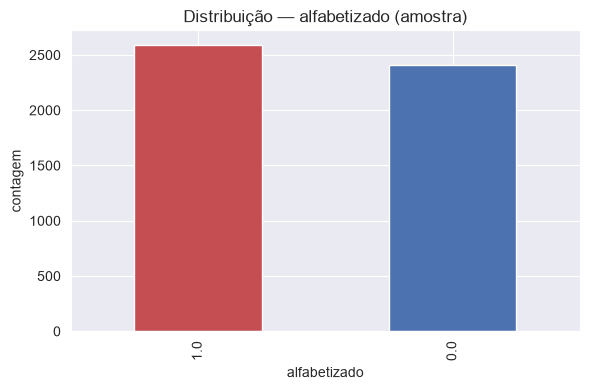

In [12]:
print("Distribuição do target:")
display(target_balance(df))

plt.figure(figsize=(6, 4))
df[TARGET_COL].value_counts(dropna=False).plot(kind="bar", color=["#c44e52", "#4c72b0"])
plt.title("Distribuição — alfabetizado (amostra)")
plt.xlabel(TARGET_COL)
plt.ylabel("contagem")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "eda_target_distribution.png", dpi=120)
plt.show()

Interessante observar se a amostra está equilibrada. Se uma classe dominar demais, na modelagem priorizamos métricas como **F1 / recall** e, se preciso, `class_weight`.

### Análise por rede e território

Pergunta: a taxa média de alfabetização na amostra muda entre redes e regiões?

,taxa_media_alfabetizado
rede,
estadual,0.550075
municipal,0.513507


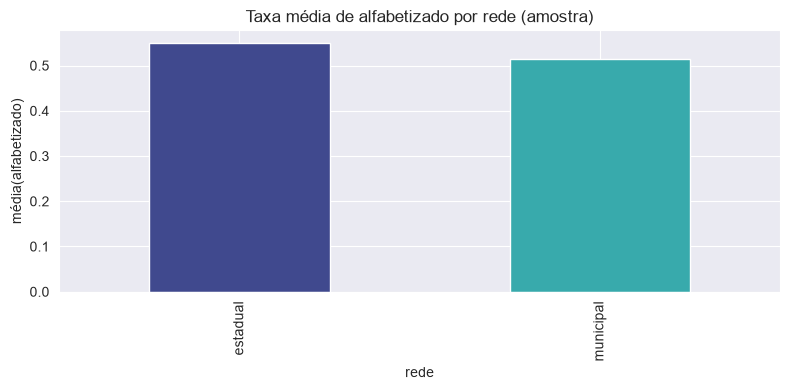

In [13]:
if "rede" in df.columns:
    taxa_rede = df.groupby("rede")[TARGET_COL].mean().sort_values(ascending=False)
    display(taxa_rede.to_frame("taxa_media_alfabetizado"))

    plt.figure(figsize=(8, 4))
    taxa_rede.plot(kind="bar", color=sns.color_palette("mako", len(taxa_rede)))
    plt.title("Taxa média de alfabetizado por rede (amostra)")
    plt.ylabel(f"média({TARGET_COL})")
    plt.tight_layout()
    plt.savefig(IMAGES_DIR / "eda_rede_vs_target.png", dpi=120)
    plt.show()

,taxa_media_alfabetizado
nome_regiao,
Centro-Oeste,0.600462
Sudeste,0.538541
Nordeste,0.522340
Sul,0.489771
Norte,0.421329


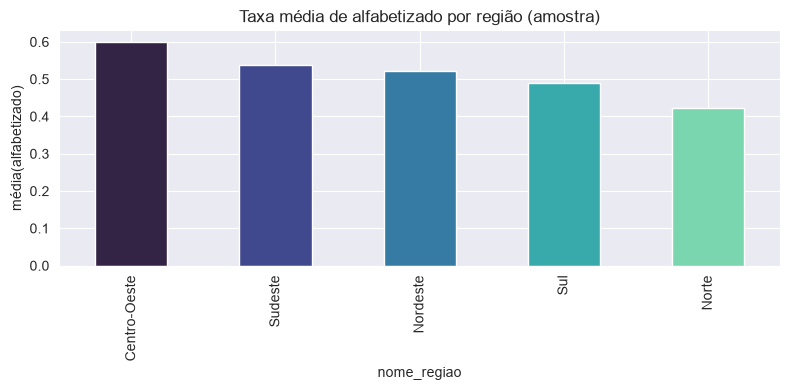

In [14]:
if "nome_regiao" in df.columns and df["nome_regiao"].notna().any():
    taxa_regiao = df.groupby("nome_regiao")[TARGET_COL].mean().sort_values(ascending=False)
    display(taxa_regiao.to_frame("taxa_media_alfabetizado"))

    plt.figure(figsize=(8, 4))
    taxa_regiao.plot(kind="bar", color=sns.color_palette("mako", len(taxa_regiao)))
    plt.title("Taxa média de alfabetizado por região (amostra)")
    plt.ylabel(f"média({TARGET_COL})")
    plt.tight_layout()
    plt.savefig(IMAGES_DIR / "eda_nome_regiao_vs_target.png", dpi=120)
    plt.show()
else:
    print("nome_regiao sem valores preenchidos após o merge nesta amostra.")

Se houver diferença clara entre redes/regiões, isso reforça a hipótese de que **variáveis territoriais** devem entrar no modelo (com encoding categórico).

### Distribuições numéricas

Olhamos PIB per capita, IVS e lags — candidatas fortes a features.

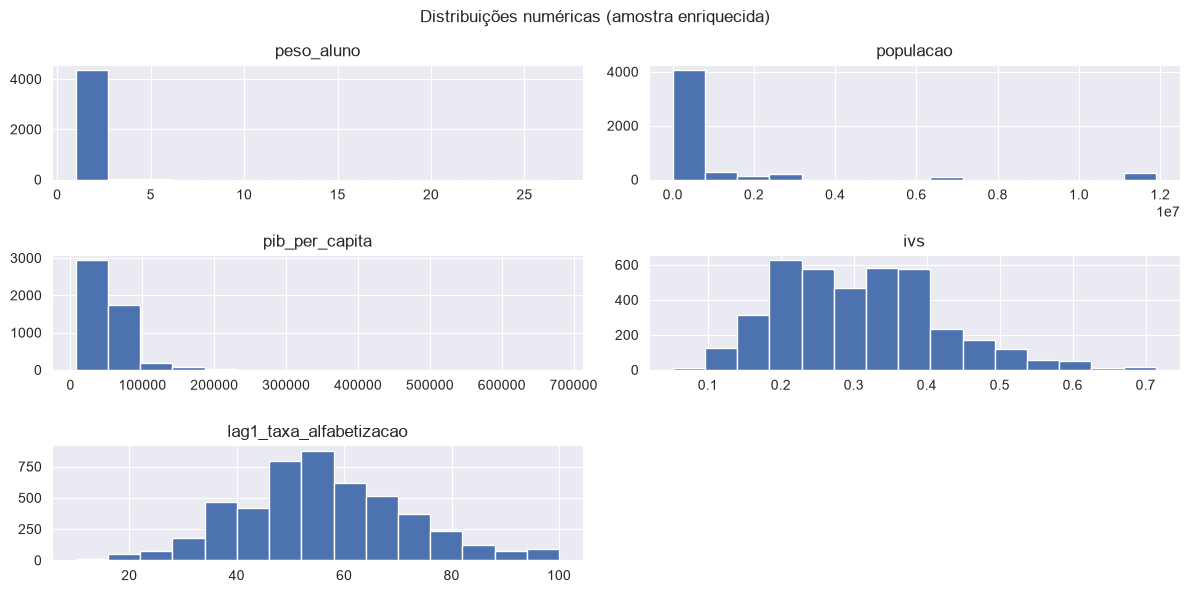

In [15]:
num_plot = [
    c
    for c in ["peso_aluno", "populacao", "pib_per_capita", "ivs", "lag1_taxa_alfabetizacao"]
    if c in df.columns and df[c].notna().any()
]

if num_plot:
    df[num_plot].hist(bins=15, figsize=(12, 6), color="#4c72b0", edgecolor="white")
    plt.suptitle("Distribuições numéricas (amostra enriquecida)")
    plt.tight_layout()
    plt.savefig(IMAGES_DIR / "eda_numeric_distributions.png", dpi=120)
    plt.show()
else:
    print("Sem colunas numéricas preenchidas para histograma nesta amostra.")

### Pairplot / relações

Aqui buscamos relações entre contexto socioeconômico e o target.

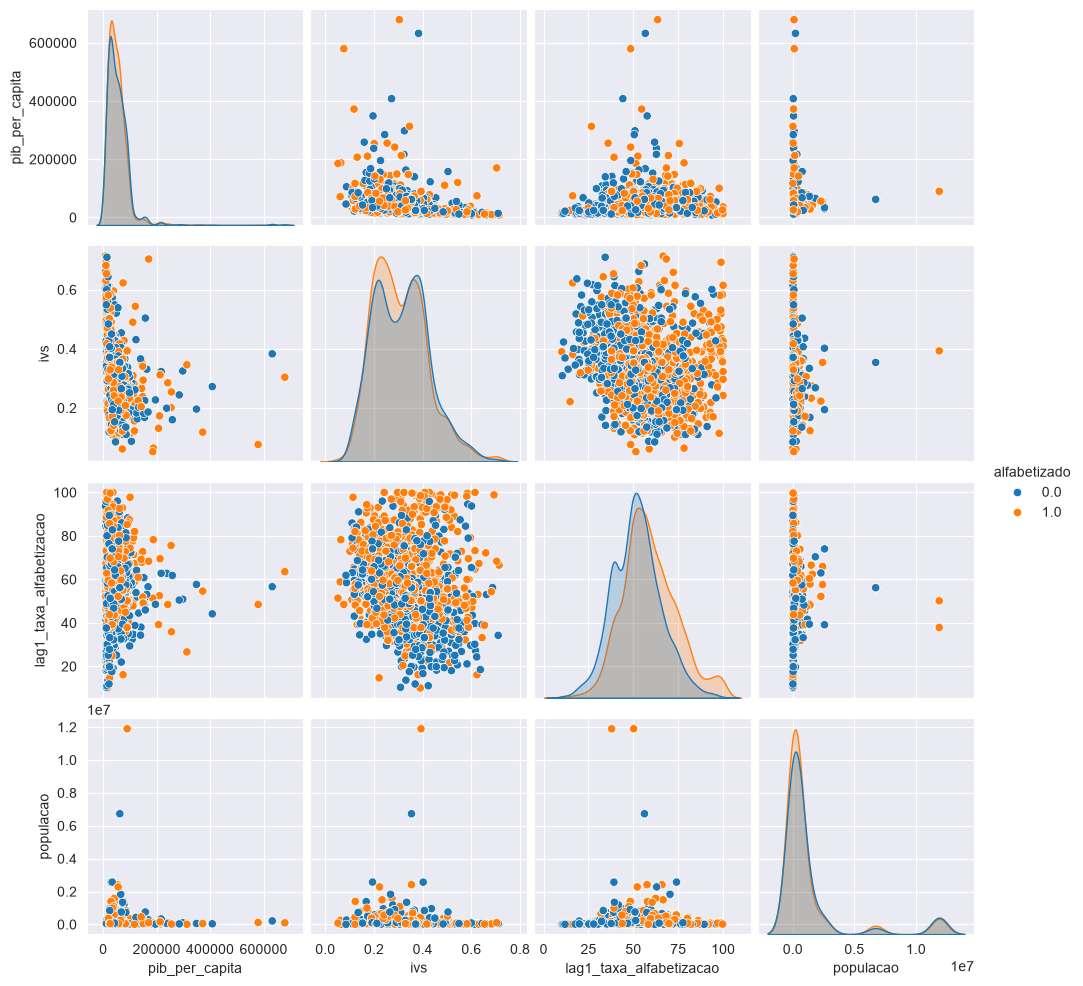

In [16]:
pair_cols = [
    c
    for c in [TARGET_COL, "pib_per_capita", "ivs", "lag1_taxa_alfabetizacao", "populacao"]
    if c in df.columns and df[c].notna().any()
]

if len(pair_cols) >= 3:
    sns.pairplot(df[pair_cols].dropna(), hue=TARGET_COL if TARGET_COL in pair_cols else None)
    plt.show()
else:
    print("Amostra insuficiente de colunas preenchidas para pairplot.")

Interessante observar se `ivs` / `pib_per_capita` / `lag1_taxa_alfabetizacao` se separam visualmente entre alfabetizados e não alfabetizados. Isso guia a priorização de features.

### Correlações

Matriz de correlação entre variáveis numéricas relevantes e o target (amostra — provisória).

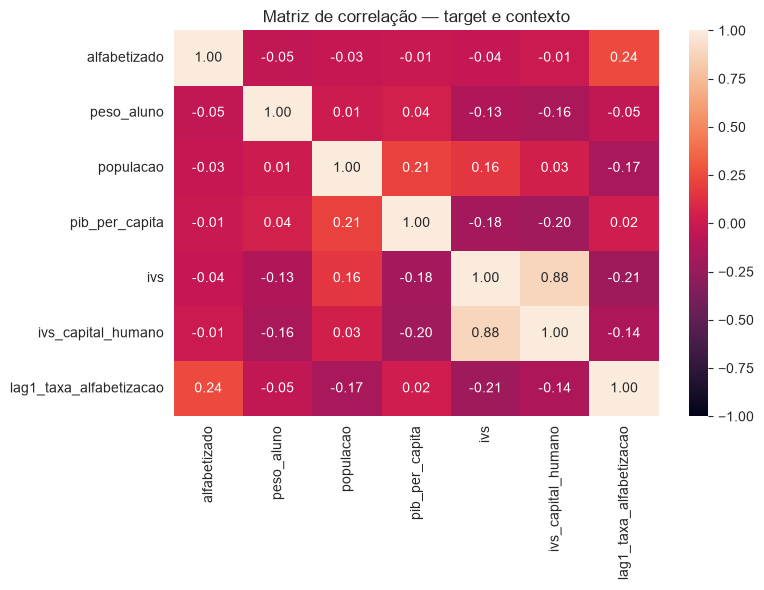

Correlação com o target (amostra):


nivel_alfabetizacao           0.308271
meta_alfabetizacao_2029       0.249869
meta_alfabetizacao_2025       0.249098
meta_alfabetizacao_2028       0.249082
meta_alfabetizacao_2026       0.248654
meta_alfabetizacao_2027       0.248634
meta_alfabetizacao_2024       0.246881
lag1_media_portugues          0.246826
lag1_taxa_alfabetizacao       0.243055
lag1_uf_media_portugues       0.197272
lag1_uf_taxa_alfabetizacao    0.188007
uf_meta_alfabetizacao_2028    0.182436
uf_meta_alfabetizacao_2029    0.182341
uf_meta_alfabetizacao_2027    0.181620
uf_meta_alfabetizacao_2026    0.181358
Name: alfabetizado, dtype: float64

In [17]:
cols_corr = [
    c
    for c in [
        TARGET_COL,
        "peso_aluno",
        "populacao",
        "pib_per_capita",
        "ivs",
        "ivs_capital_humano",
        "lag1_taxa_alfabetizacao",
    ]
    if c in df.columns and df[c].notna().any()
]

if len(cols_corr) >= 2:
    corr = df[cols_corr].corr(numeric_only=True)
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="rocket", vmin=-1, vmax=1)
    plt.title("Matriz de correlação — target e contexto")
    plt.tight_layout()
    plt.savefig(IMAGES_DIR / "eda_correlation_heatmap.png", dpi=120)
    plt.show()

    print("Correlação com o target (amostra):")
    display(correlation_with_target(df))
else:
    print("Poucas colunas numéricas preenchidas para correlação nesta amostra.")

### Indicadores agregados (município e UF)

Essas bases respondem perguntas de **negócio** (metas, risco municipal), não o grain do classificador de aluno.

Indicador município — preview


,id_municipio,rede,total_alunos,total_peso,total_alfabetizados_ponderado,proficiencia_media_ponderada,taxa_crianca_alfabetizada,taxa_alfabetizacao,meta_alfabetizacao_2024,meta_alfabetizacao_2025,meta_alfabetizacao_2026,meta_alfabetizacao_2027,meta_alfabetizacao_2028,meta_alfabetizacao_2029,meta_alfabetizacao_2030,nome_municipio,nome_uf,sigla_uf,percentual_participacao,regiao_municipio,...,gap_taxa_vs_inep,gap_meta_2024,gap_meta_2025,gap_meta_2026,gap_meta_2027,gap_meta_2028,gap_meta_2029,gap_meta_2030,nome_regiao,brasil_taxa_alfabetizacao,brasil_meta_alfabetizacao_2024,brasil_meta_alfabetizacao_2025,brasil_meta_alfabetizacao_2026,brasil_meta_alfabetizacao_2027,brasil_meta_alfabetizacao_2028,brasil_meta_alfabetizacao_2029,brasil_meta_alfabetizacao_2030,brasil_percentual_participacao,_gold_processed_at,_gold_batch_id
0,1100015,municipal,306.0,337.29,207.69,683.355926,61.576092,67.79,67.08,69.51,71.84,74.06,76.16,78.14,80.0,Alta Floresta D'Oeste,Rondônia,RO,89.87,Norte,...,-6.213908,-5.503908,-7.933908,-10.263908,-12.483908,-14.583908,-16.563908,-18.423908,Norte,59.2,59.9,63.77,67.47,70.97,74.23,77.24,80.0,87.37,2026-09-01T22:44:22.267804+00:00,1a06cc53-5440-40c5-91b1-c670bc3bbd5d
1,1100023,municipal,1201.0,1336.01,788.07,672.561836,58.986834,65.62,65.22,68.02,70.71,73.25,75.65,77.90,80.0,Ariquemes,Rondônia,RO,88.76,Norte,...,-6.633166,-6.233166,-9.033166,-11.723166,-14.263166,-16.663166,-18.913166,-21.013166,Norte,59.2,59.9,63.77,67.47,70.97,74.23,77.24,80.0,87.37,2026-09-01T22:44:22.267804+00:00,1a06cc53-5440-40c5-91b1-c670bc3bbd5d
2,1100031,municipal,81.0,86.96,61.45,707.252871,70.664673,75.88,70.85,72.53,74.15,75.71,77.21,78.64,80.0,Cabixi,Rondônia,RO,92.59,Norte,...,-5.215327,-0.185327,-1.865327,-3.485327,-5.045327,-6.545327,-7.975327,-9.335327,Norte,59.2,59.9,63.77,67.47,70.97,74.23,77.24,80.0,87.37,2026-09-01T22:44:22.267804+00:00,1a06cc53-5440-40c5-91b1-c670bc3bbd5d


,count,mean,std,min,25%,50%,75%,max
total_alunos,6543.0,324.10,1436.79,10.00,47.00,100.00,239.00,58618.00
total_peso,6543.0,363.42,1633.80,10.00,51.92,109.11,261.59,64607.21
total_alfabetizados_ponderado,6543.0,190.83,844.88,0.00,28.00,60.91,145.71,36737.14
proficiencia_media_ponderada,6543.0,687.77,61.05,0.00,657.32,692.25,724.84,868.01
taxa_crianca_alfabetizada,6543.0,57.72,19.30,0.00,43.42,58.08,72.00,100.00
taxa_alfabetizacao,5352.0,63.04,19.25,4.40,48.73,64.25,77.71,100.00
meta_alfabetizacao_2024,5232.0,62.15,15.10,7.94,52.17,64.10,75.88,80.00
meta_alfabetizacao_2025,5352.0,65.25,12.63,14.05,57.11,66.94,76.51,80.00
meta_alfabetizacao_2026,5352.0,68.56,9.86,23.65,62.40,69.88,77.24,80.00
meta_alfabetizacao_2027,5352.0,71.77,7.06,37.00,67.40,72.66,77.95,80.00


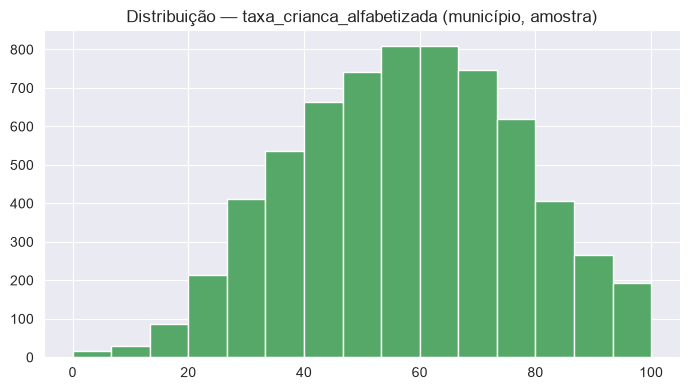

In [18]:
print("Indicador município — preview")
display(ind_mun.head(3))
display(ind_mun.describe().round(2).T.head(12))

if "taxa_crianca_alfabetizada" in ind_mun.columns:
    plt.figure(figsize=(7, 4))
    ind_mun["taxa_crianca_alfabetizada"].dropna().hist(bins=15, color="#55a868", edgecolor="white")
    plt.title("Distribuição — taxa_crianca_alfabetizada (município, amostra)")
    plt.tight_layout()
    plt.show()

Indicador UF — preview


,sigla_uf,rede,total_alunos,total_peso,total_alfabetizados_ponderado,proficiencia_media_ponderada,taxa_crianca_alfabetizada,taxa_alfabetizacao,meta_alfabetizacao_2024,meta_alfabetizacao_2025,meta_alfabetizacao_2026,meta_alfabetizacao_2027,meta_alfabetizacao_2028,meta_alfabetizacao_2029,meta_alfabetizacao_2030,nome_uf,percentual_participacao,regiao_uf,gap_taxa_vs_inep,gap_meta_2024,gap_meta_2025,gap_meta_2026,gap_meta_2027,gap_meta_2028,gap_meta_2029,gap_meta_2030,brasil_taxa_alfabetizacao,brasil_meta_alfabetizacao_2024,brasil_meta_alfabetizacao_2025,brasil_meta_alfabetizacao_2026,brasil_meta_alfabetizacao_2027,brasil_meta_alfabetizacao_2028,brasil_meta_alfabetizacao_2029,brasil_meta_alfabetizacao_2030,brasil_percentual_participacao,_gold_processed_at,_gold_batch_id
0,AC,estadual,5557.0,6630.23,3085.46,623.126790,46.536244,51.38,NaN,56.9,62.2,67.3,72.0,76.2,80.0,Acre,80.87,Norte,-4.843756,NaN,-10.363756,-15.663756,-20.763756,-25.463756,-29.663756,-33.463756,59.2,59.9,63.77,67.47,70.97,74.23,77.24,80.0,87.37,2026-09-01T22:44:38.243234+00:00,1a06cc53-5440-40c5-91b1-c670bc3bbd5d
1,AC,municipal,7098.0,8448.80,3418.70,618.399267,40.463734,51.38,NaN,56.9,62.2,67.3,72.0,76.2,80.0,Acre,80.87,Norte,-10.916266,NaN,-16.436266,-21.736266,-26.836266,-31.536266,-35.736266,-39.536266,59.2,59.9,63.77,67.47,70.97,74.23,77.24,80.0,87.37,2026-09-01T22:44:38.243234+00:00,1a06cc53-5440-40c5-91b1-c670bc3bbd5d
2,AL,estadual,1520.0,1681.07,606.74,656.814323,36.092489,48.63,49.7,55.5,61.1,66.5,71.5,76.0,80.0,Alagoas,93.78,Nordeste,-12.537511,-13.607511,-19.407511,-25.007511,-30.407511,-35.407511,-39.907511,-43.907511,59.2,59.9,63.77,67.47,70.97,74.23,77.24,80.0,87.37,2026-09-01T22:44:38.243234+00:00,1a06cc53-5440-40c5-91b1-c670bc3bbd5d
3,AL,municipal,32148.0,34087.87,15771.71,694.225475,46.267807,48.63,49.7,55.5,61.1,66.5,71.5,76.0,80.0,Alagoas,93.78,Nordeste,-2.362193,-3.432193,-9.232193,-14.832193,-20.232193,-25.232193,-29.732193,-33.732193,59.2,59.9,63.77,67.47,70.97,74.23,77.24,80.0,87.37,2026-09-01T22:44:38.243234+00:00,1a06cc53-5440-40c5-91b1-c670bc3bbd5d
4,AM,estadual,13529.0,15957.86,7871.70,628.929026,49.328043,49.17,56.8,61.3,65.6,69.6,73.4,76.9,80.0,Amazonas,79.49,Norte,0.158043,-7.471957,-11.971957,-16.271957,-20.271957,-24.071957,-27.571957,-30.671957,59.2,59.9,63.77,67.47,70.97,74.23,77.24,80.0,87.37,2026-09-01T22:44:38.243234+00:00,1a06cc53-5440-40c5-91b1-c670bc3bbd5d


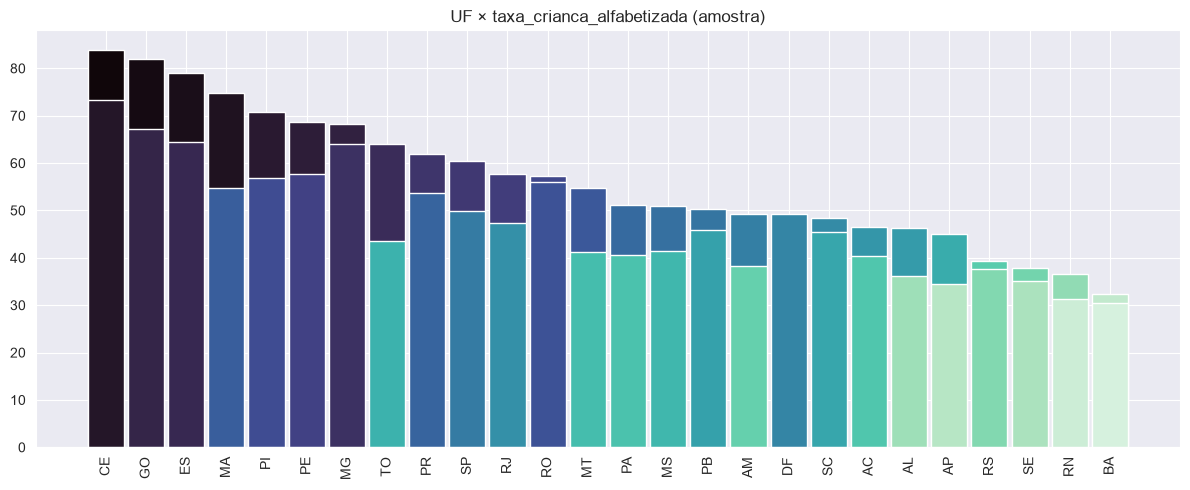

In [19]:
print("Indicador UF — preview")
display(ind_uf.head(5))

if {"sigla_uf", "taxa_crianca_alfabetizada"}.issubset(ind_uf.columns):
    tmp = ind_uf.dropna(subset=["taxa_crianca_alfabetizada"]).sort_values(
        "taxa_crianca_alfabetizada", ascending=False
    )
    plt.figure(figsize=(12, 5))
    pal = sns.color_palette("mako", len(tmp))
    plt.bar(tmp["sigla_uf"].astype(str), tmp["taxa_crianca_alfabetizada"], color=pal, width=0.9)
    plt.title("UF × taxa_crianca_alfabetizada (amostra)")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.savefig(IMAGES_DIR / "eda_uf_taxa.png", dpi=120)
    plt.show()

Esse tipo de visão por UF ajuda a responder: *quais estados/municípios apresentam maior risco educacional?* — pergunta estratégica do Tech Challenge.

### Features candidatas vs leakage

Resumo do que deve (e não deve) ir para a pipeline Scikit-learn.

In [20]:
feats = feature_columns(df)
num, cat = split_feature_types(df, feats)

print(f"Features candidatas: {len(feats)}")
print(f"Numéricas ({len(num)}):", num)
print(f"Categóricas ({len(cat)}):", cat)
print("\nExcluir do modelo:", [c for c in LEAKAGE_COLS if c in alunos.columns or c in df.columns])

Features candidatas: 51
Numéricas (39): ['peso_aluno', 'meta_alfabetizacao_2024', 'meta_alfabetizacao_2025', 'meta_alfabetizacao_2026', 'meta_alfabetizacao_2027', 'meta_alfabetizacao_2028', 'meta_alfabetizacao_2029', 'meta_alfabetizacao_2030', 'nivel_alfabetizacao', 'capital_uf', 'amazonia_legal', 'uf_meta_alfabetizacao_2024', 'uf_meta_alfabetizacao_2025', 'uf_meta_alfabetizacao_2026', 'uf_meta_alfabetizacao_2027', 'uf_meta_alfabetizacao_2028', 'uf_meta_alfabetizacao_2029', 'uf_meta_alfabetizacao_2030', 'brasil_meta_alfabetizacao_2024', 'brasil_meta_alfabetizacao_2025', 'brasil_meta_alfabetizacao_2026', 'brasil_meta_alfabetizacao_2027', 'brasil_meta_alfabetizacao_2028', 'brasil_meta_alfabetizacao_2029', 'brasil_meta_alfabetizacao_2030', 'populacao', 'populacao_ano_ref', 'pib', 'pib_ano_ref', 'pib_per_capita', 'socio_ano_ref', 'ivs', 'ivs_infraestrutura_urbana', 'ivs_capital_humano', 'ivs_renda_trabalho', 'lag1_taxa_alfabetizacao', 'lag1_media_portugues', 'lag1_uf_taxa_alfabetizacao', '

### Hipóteses analíticas

| # | Hipótese | Variáveis | Implicação para modelagem |
|---|----------|-----------|---------------------------|
| H1 | Contexto socioeconômico influencia a chance de alfabetização | `ivs*`, `pib_per_capita`, `populacao` | Incluir + imputar missing |
| H2 | Histórico municipal (lag) é preditivo com menor risco de leakage | `lag1_*` | Preferir lags a taxas do mesmo evento |
| H3 | Região e rede escolar alteram a taxa de alfabetização | `nome_regiao`, `sigla_uf`, `rede` | One-hot / encoding |
| H4 | Metas sozinhas não explicam o aluno | `meta_alfabetizacao_*` | Usar com cautela |

**Decisões de modelagem (a partir desta EDA):**
1. Grain = **aluno**; target = **`alfabetizado`**
2. Enriquecer fato aluno com `contexto_territorio` (`id_municipio`, `rede`)
3. Remover `id_aluno` e metadados `_silver_*` / `_gold_*`; usar `nivel_alfabetizacao` como feature se a Gold expuser
4. Pipeline: imputação + scaling (num) e imputação + one-hot (cat)
5. Revalidar em amostra maior / Gold S3 antes do treino final

**Amostragem e partição (revisão):** EDA e modelagem usam `ano=2024` com peek aleatório. `nivel_alfabetizacao` é municipal. Split de treino/teste deve ser agrupado por `id_municipio`.


In [21]:
images = sorted(IMAGES_DIR.glob("eda_*.png"))
report = write_eda_report(tables, images, enriched=df)
print("Relatório escrito em:", report)

Relatório escrito em: C:\Users\IWalt\OneDrive\Documents\GitHub\tech-challenge-fase3\reports\eda.md
